### 1.8 Tapering in Filtering: A Stronger Edge-Effect Example

The earlier example showed the basic idea of ringing, but the effect can still look subtle.

Here we build a more extreme case so the artifact is easier to see.

We start with a clean 5 Hz sine wave, then deliberately create a **sharp discontinuity** at the start and end of the record.  
After that, we apply a narrow bandpass filter centered near 5 Hz.

We compare:

1. filtering **without tapering**
2. filtering **with tapering**

The goal is to make the edge artifact obvious.

#### Why this example is stronger

This example exaggerates the edge problem in three ways:

- the signal is shifted upward with a DC offset
- the first and last samples are forced to jump sharply
- the filter is fairly narrow, so it rings more clearly

This is not meant to be realistic. It is meant to make the mechanism easy to see.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, windows

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 12,
    'lines.linewidth': 2,
})

sampling_rate = 100.0
t = np.arange(0, 2.0, 1 / sampling_rate)

# Clean signal of interest
x_clean = np.sin(2 * np.pi * 5 * t)

# Create a stronger edge problem:
# 1) shift signal upward
# 2) force sharp jumps at the first and last samples
x_edge = x_clean + 2.0
x_edge[0] = -3.0
x_edge[-1] = 3.0

# Tapered version of the same input
taper = windows.tukey(len(x_edge), alpha=0.3)
x_tapered = x_edge * taper

# Narrow bandpass around 5 Hz to make ringing obvious
b, a = butter(8, [4.5, 5.5], btype='band', fs=sampling_rate)

# Filtered outputs
y_notaper = filtfilt(b, a, x_edge)
y_taper = filtfilt(b, a, x_tapered)

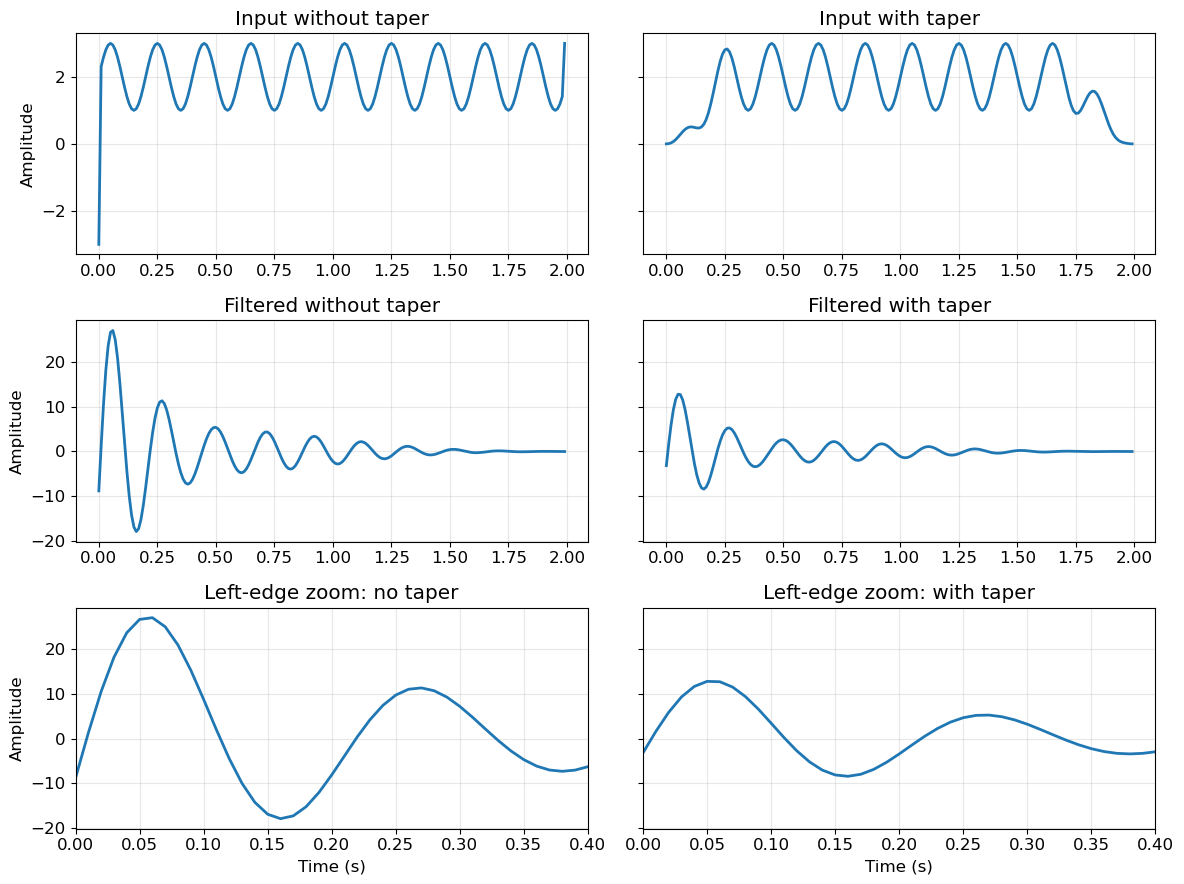

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharey='row')

# Full inputs
axes[0, 0].plot(t, x_edge)
axes[0, 0].set_title("Input without taper")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t, x_tapered)
axes[0, 1].set_title("Input with taper")
axes[0, 1].grid(True, alpha=0.3)

# Full filtered outputs
axes[1, 0].plot(t, y_notaper)
axes[1, 0].set_title("Filtered without taper")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t, y_taper)
axes[1, 1].set_title("Filtered with taper")
axes[1, 1].grid(True, alpha=0.3)

# Zoom on left edge
axes[2, 0].plot(t, y_notaper)
axes[2, 0].set_xlim(0, 0.4)
axes[2, 0].set_title("Left-edge zoom: no taper")
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(t, y_taper)
axes[2, 1].set_xlim(0, 0.4)
axes[2, 1].set_title("Left-edge zoom: with taper")
axes[2, 1].grid(True, alpha=0.3)

for ax in axes[:, 0]:
    ax.set_ylabel("Amplitude")
for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

#### What to look for

In the **filtered without taper** panel, the sharp edge forces the filter to create oscillations near the boundary.

These oscillations:

- are large
- are localized near the edge
- are not part of the physical signal

In the **filtered with taper** panel, the edge is smoothed before filtering, so the ringing is much smaller.

> The artifact is produced by the filter reacting to the discontinuity.

In [3]:
left_notaper = np.max(np.abs(y_notaper[:40]))
left_taper = np.max(np.abs(y_taper[:40]))
right_notaper = np.max(np.abs(y_notaper[-40:]))
right_taper = np.max(np.abs(y_taper[-40:]))

print("Maximum absolute amplitude near the left edge:")
print(f"  without taper = {left_notaper:.3f}")
print(f"  with taper    = {left_taper:.3f}")

print("\nMaximum absolute amplitude near the right edge:")
print(f"  without taper = {right_notaper:.3f}")
print(f"  with taper    = {right_taper:.3f}")

if left_taper > 0:
    print(f"\nLeft-edge artifact is about {left_notaper/left_taper:.1f}x larger without taper.")

Maximum absolute amplitude near the left edge:
  without taper = 27.118
  with taper    = 12.840

Maximum absolute amplitude near the right edge:
  without taper = 0.278
  with taper    = 0.136

Left-edge artifact is about 2.1x larger without taper.


#### Key Takeaway

A sharp edge contains a broad range of frequencies.  
When we apply a narrow bandpass filter, the filter responds by producing oscillations near that edge.

Tapering reduces the discontinuity, so the ringing is reduced as well.

This is why tapering is often a good idea before filtering finite time series.